# # Task 7: Basic Sales Summary Using SQLite and Python

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## Create SQLite Database Connection

In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

print("Database Connected Successfully!")

Database Connected Successfully!


## Create Sales Table

In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price INTEGER
)
""")

print("Table Created Successfully!")

Table Created Successfully!


## Insert Sample Sales Data

In [4]:
sales_data = [
    ("Laptop", 2, 50000),
    ("Mouse", 5, 500),
    ("Keyboard", 3, 1200),
    ("Laptop", 1, 50000),
    ("Mouse", 2, 500)
]

cursor.executemany("""
INSERT INTO sales (product, quantity, price)
VALUES (?, ?, ?)
""", sales_data)

conn.commit()

print("Data Inserted Successfully!")

Data Inserted Successfully!


## Display Sales Data

In [6]:
df = pd.read_sql_query("SELECT * FROM sales", conn)

print(df)

    product  quantity  price
0    Laptop         2  50000
1     Mouse         5    500
2  Keyboard         3   1200
3    Laptop         1  50000
4     Mouse         2    500


## Execute SQL Query

In [9]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product;
"""

sales_summary = pd.read_sql_query(query, conn)

print(sales_summary)

    product  total_qty  revenue
0  Keyboard          3     3600
1    Laptop          3   150000
2     Mouse          7     3500


## Revenue Bar Chart

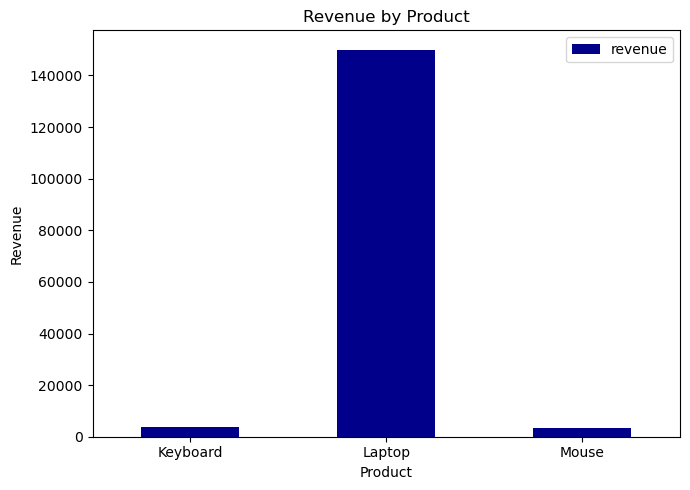

In [15]:
sales_summary.plot(
    kind="bar",
    x="product",
    y="revenue",
    figsize=(7,5),
    color="darkblue"
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("sales_chart.png") 

plt.show()

## Close Database Connection

In [12]:
conn.close()
print("Database connection closed.")

Database connection closed.
